In [133]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Custom settings
plt.style.use('classic')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['axes.edgecolor'] = 'black'
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['savefig.facecolor'] = 'white'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['figure.dpi'] = 100

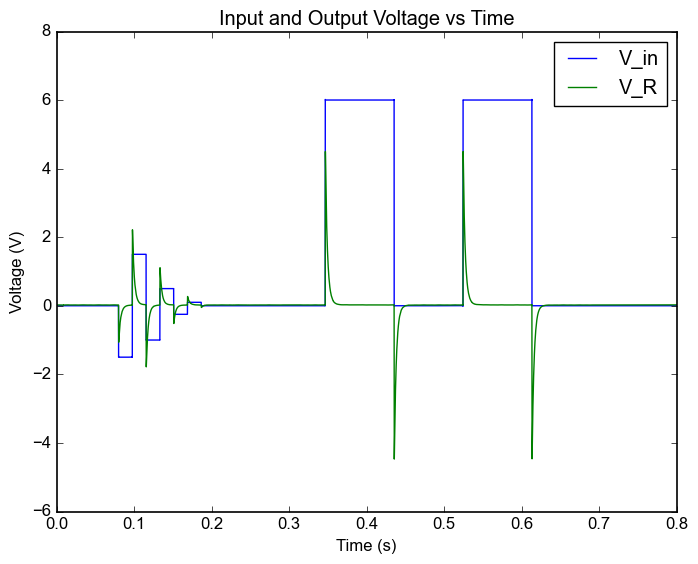

In [134]:
data1 = np.loadtxt("./Data/20262704001.dat")
data2 = np.loadtxt("./Data/20262704001.snp")

R = 100e3  # Resistance in ohms

t = data1[:, 0]
V_R = data1[:, 1]
main_trigger = data1[:, 2]
V_in = data1[:, 3]
second_trigger = data1[:, 4]
I = data1[:, 5]


plt.plot(t, V_in, label='V_in')
plt.plot(t, V_R*10, label='V_R')
plt.xlabel('Time (s)')
plt.ylabel('Voltage (V)')
# plt.xlim(0.02, 0.22)

plt.title('Input and Output Voltage vs Time')
plt.legend()
plt.show()


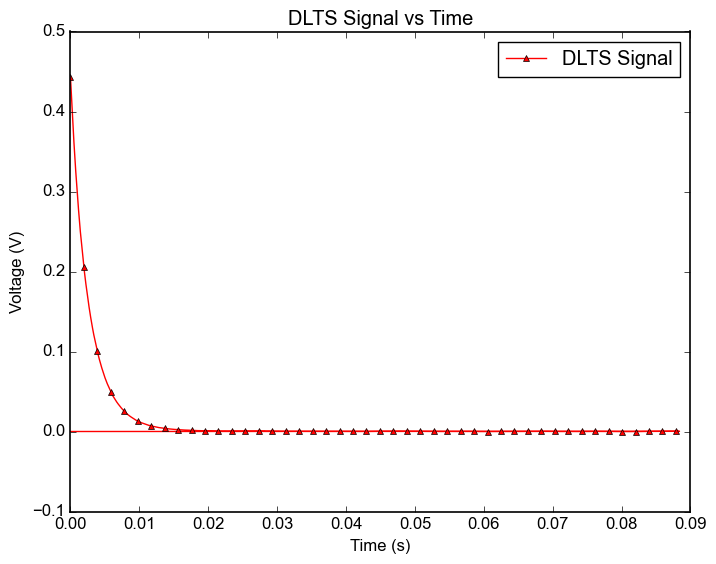

In [135]:
t = data2[:, 0]
V = data2[:, 1]

plt.plot(t, V, label='DLTS Signal', color='red', linestyle='-', marker='^', markersize=4, markevery=200)
plt.xlabel('Time (s)')
plt.ylabel('Voltage (V)')
plt.title('DLTS Signal vs Time')
plt.legend(frameon=True, numpoints=1)
plt.show()


a = 0.391 ± 0.0048
b = 0.00337 ± 0.000126
c (time constant) = -0.0151 ± 0.00466 s
R^2 = 0.871
C (fitted) = (-150.507 ± 46.609) nF
C (actual) = 2.100 nF
Difference = 7266.99%


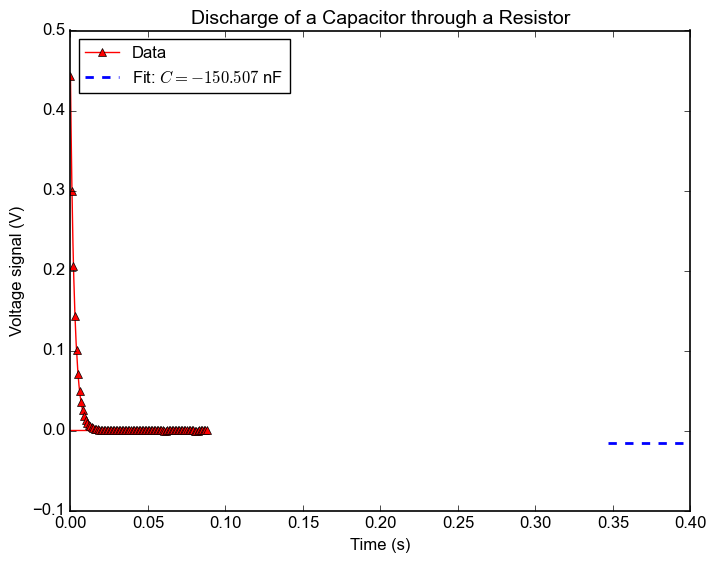

In [136]:
def func(x, a, b, c):
    return a * np.exp(-x / b) + c

# Find the rising/falling edge and fit to the decay region
# Adjust time window to capture the exponential decay (starting earlier)
mask = np.isfinite(t) & np.isfinite(V) & (t >= 0.00) & (t <= 0.01)
popt, pcov = curve_fit(func, t[mask], V[mask])
sigma_fit = func(t[mask], *popt)
a, b, c = popt

# Coefficient of determination
ss_res = np.sum((V[mask] - sigma_fit) ** 2)
ss_tot = np.sum((V[mask] - np.mean(V[mask])) ** 2)
r2 = 1 - (ss_res / ss_tot)

# 1-sigma parameter uncertainties from covariance matrix
perr = np.sqrt(np.diag(pcov))
a_err, b_err, c_err = perr
C = c / R
C_err = c_err / R

# Known capacitor value
C_actual = 2.1e-9  # 2.1 nF in Farads

print(f"a = {a:.3g} ± {a_err:.3g}")
print(f"b = {b:.3g} ± {b_err:.3g}")
print(f"c (time constant) = {c:.3g} ± {c_err:.3g} s")
print(f"R^2 = {r2:.3f}")

print(f"C (fitted) = ({C*1e9:.3f} ± {C_err*1e9:.3f}) nF")
print(f"C (actual) = {C_actual*1e9:.3f} nF")
print(f"Difference = {abs(C - C_actual)/C_actual * 100:.2f}%")

x = np.linspace(0.347, 0.4, 100)
plt.plot(t, V, '^', label='Data', color='red', markersize=6, linestyle='-', markevery=100)
plt.plot(x, func(x, *popt) , lw=2, label=rf'Fit: $C={C*1e9:.3f}$ nF', color='blue', linestyle='--')
plt.xlabel(r"Time (s)")
plt.ylabel(r"Voltage signal (V)")
# plt.xlim(0.34, 0.4)
# plt.ylim(0, 6)
plt.legend(frameon=True, loc='upper left', numpoints=1, fontsize=12)
plt.title("Discharge of a Capacitor through a Resistor", fontsize=14)
# plt.savefig("conductance_PS9.eps", format='eps', bbox_inches='tight')
plt.show()